In [2]:
import pickle
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error
df=pd.read_csv('Bengaluru_House_Data.csv.xls')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
#Drop unwanted column
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [8]:
# Handling Missing valued in Location
df['location'].value_counts()
df['location']=df['location'].fillna('sarjapur Road')

#Handling Missing valued in size
df['size'].value_counts()
df['size']=df['size'].fillna('2 BHK')
#Handling Missing valued in size
df['bath'].value_counts()
df['bath']=df['bath'].fillna(df['bath'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [10]:
df['size'].unique()
out=[int(i.split()[0] )for i in df['size']]
df['bhk']=out
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 624.5+ KB


In [11]:
#outliers
df[df['bhk']>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [12]:
df['total_sqft'].unique()
def convert(a):
    l=a.split('-')
    if len(l)==2:
        return(float(l[0])+float(l[1]))/2
    try:
        return float(a)
    except:
        return None
df['total_sqft']=df['total_sqft'].apply(convert)

In [13]:
df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [16]:
#price per sqr.ft
df['price_per_sqft']=df['price']*100000/df['total_sqft']
df['price_per_sqft']

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_per_sqft, Length: 13320, dtype: float64

In [20]:
#cleaning location column
df['location'] =df['location'].apply(lambda x:x.strip())
df['location'].value_counts()
loc_lessthan_10 =df['location'].value_counts()
loc_lessthan_10 =loc_lessthan_10[loc_lessthan_10<=10]
loc_lessthan_10

location
BTM 1st Stage                         10
Nagadevanahalli                       10
Basapura                              10
Sector 1 HSR Layout                   10
Dairy Circle                          10
                                      ..
1Channasandra                          1
Hosahalli                              1
Vijayabank bank layout                 1
near Ramanashree California resort     1
Abshot Layout                          1
Name: count, Length: 1054, dtype: int64

In [21]:
df['location'] =df['location'].apply(lambda x:'other' if x in loc_lessthan_10 else x)

In [22]:
df['location'].value_counts()

location
other                 2886
Whitefield             541
Sarjapur  Road         399
Electronic City        304
Kanakpura Road         273
                      ... 
Nehru Nagar             11
Banjara Layout          11
LB Shastri Nagar        11
Pattandur Agrahara      11
Narayanapura            11
Name: count, Length: 242, dtype: int64

In [23]:
#total sqr.ft per bhk
(df['total_sqft']/df['bhk']).describe()

count    13274.000000
mean       575.074878
std        388.205175
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [24]:
#fetch the data where total sqr.ft per bhk is more than 300
df =df[(df['total_sqft']/df['bhk'])>300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12348.000000,12348.000000,12348.000000,12348.000000,12348.000000
mean,1601.084689,2.542274,110.823169,2.633301,6207.869136
std,1268.788019,1.065177,152.794399,0.964402,4047.666274
min,340.000000,1.000000,8.440000,1.000000,267.829813
25%,1115.000000,2.000000,49.000000,2.000000,4200.000000
50%,1305.000000,2.000000,69.475000,3.000000,5264.632169
75%,1708.000000,3.000000,115.000000,3.000000,6825.108836
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [26]:
#to keep onlyb realistic rows where the total square footage
df =df[df['total_sqft']>=df['bhk']*300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12348.000000,12348.000000,12348.000000,12348.000000,12348.000000
mean,1601.084689,2.542274,110.823169,2.633301,6207.869136
std,1268.788019,1.065177,152.794399,0.964402,4047.666274
min,340.000000,1.000000,8.440000,1.000000,267.829813
25%,1115.000000,2.000000,49.000000,2.000000,4200.000000
50%,1305.000000,2.000000,69.475000,3.000000,5264.632169
75%,1708.000000,3.000000,115.000000,3.000000,6825.108836
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


<Axes: xlabel='price_per_sqft', ylabel='Count'>

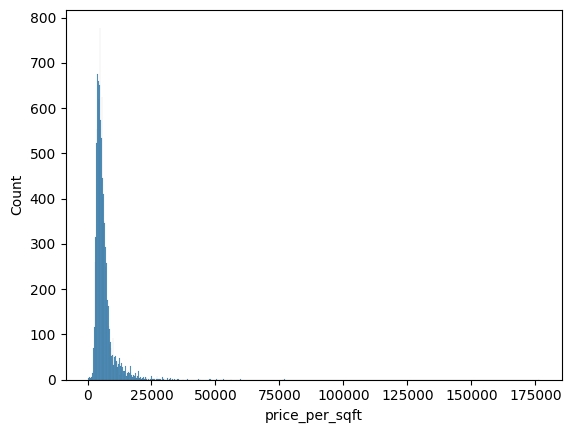

In [30]:
sns.histplot(x='price_per_sqft',data=df)
#sns.boxplot(x='price_per_sqft',data=df)

In [34]:
q1=df['price_per_sqft'].quantile(0.25)
q3=df['price_per_sqft'].quantile(0.75)
IQR =q3-q1
lower_bound =q1-0.5*IQR
upper_bound =q3+0.5*IQR
df =df[(df['price_per_sqft']>=lower_bound) & (df['price_per_sqft']<=upper_bound)]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13313,Uttarahalli,3 BHK,1345.0,2.0,57.00,3,4237.918216
13314,Green Glen Layout,3 BHK,1715.0,3.0,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136


<Axes: xlabel='price_per_sqft'>

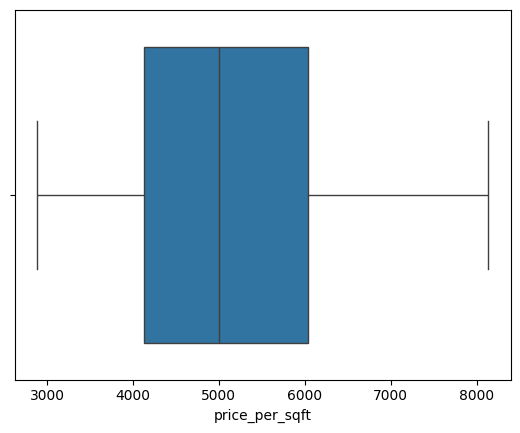

In [35]:
sns.boxplot(x='price_per_sqft',data=df)
#sns.histplot(x='price_per_sqft',data=df)

In [36]:
df =df[df['bhk']<=6]

In [37]:
df=df[df['bath'] <df['bhk'] +2]

In [38]:
df=df.drop(['size','price_per_sqft'],axis=1)
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


In [39]:
df.reset_index(inplace=True)
df =df.drop('index',axis=1)


In [40]:
cleaned =df.copy()

In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
encoder =LabelEncoder()
df['location'] =encoder.fit_transform(df[['location']])

C:\Users\puran\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [47]:
x=df.drop('price',axis=1)
y= df['price']

In [48]:
Xtrain,Xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [49]:
model=RandomForestRegressor(random_state=42)
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6]
}
grid =GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(Xtrain,ytrain)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 150, 200, 250, 300]})

In [51]:
print("Beat params:",grid.best_params_)
print("Best score:",grid.best_score_)

Beat params: {'max_depth': 6, 'n_estimators': 300}
Best score: 0.8425698371235295


In [52]:
print('Training Eff:',grid.score(Xtrain,ytrain))
print('Training Eff:',grid.score(Xtest,ytest))


Training Eff: 0.8949070448356092
Training Eff: 0.8311420994411894


In [53]:
ypred=grid.predict(Xtest)

In [54]:
print('R2:',r2_score(ytest,ypred))
print('MSE:',mean_absolute_error(ytest,ypred))

R2: 0.8311420994411894
MSE: 14.10190936937378


In [55]:
with open('Rfmodel.pkl','wb') as file:
    pickle.dump(grid,file)

In [56]:
df.head()

,location,total_sqft,bath,price,bhk
0,78,1056.0,2.0,39.07,2
1,60,2600.0,5.0,120.00,4
2,224,1440.0,2.0,62.00,3
3,158,1521.0,3.0,95.00,3
4,150,1200.0,2.0,51.00,2


In [57]:
cleaned['encoded_loc'] =df['location']
df.describe()

,location,total_sqft,bath,price,bhk
count,10104.000000,10104.000000,10104.000000,10104.000000,10104.000000
mean,151.542557,1431.708737,2.362134,75.856021,2.490202
std,75.912992,773.990562,0.773328,53.969222,0.747097
min,0.000000,340.000000,1.000000,10.000000,1.000000
25%,92.000000,1100.000000,2.000000,47.000000,2.000000
50%,160.000000,1258.000000,2.000000,63.505000,2.000000
75%,233.000000,1575.000000,3.000000,88.610000,3.000000
max,239.000000,30400.000000,7.000000,2100.000000,6.000000


In [58]:
df.bath.unique()

array([2., 5., 3., 4., 1., 6., 7.])

In [60]:
df.shape

(10104, 5)

In [62]:
df.sample(5)

,location,total_sqft,bath,price,bhk
7869,15,2650.0,4.0,175.00,3
9962,146,1140.0,2.0,50.66,2
252,131,1550.0,3.0,67.00,3
566,29,1077.0,2.0,37.64,2
9568,212,1484.0,3.0,75.00,3


/***loc=
qft
bhk
bath
grid.predict([[loc,sqft,bhk,bath]])***/